# Arboles de decisión


# **EJERCICIO 2 - Estudio de Búsquedas Laborales**

Durante un estudio realizado en una red de empresas de Estados Unidos se encuestó a **600 empleados** (archivo `busquedasLaborales.xlsx`), recolectando la siguiente información:

- Edad
- Sexo
- Cantidad de años que lleva en la empresa (menos de 1, 1 a 2, …)
- Tiene hijos a cargo (si/no)
- Nivel de educación (prim./sec./terc./univ./master/doc.)
- Grado de satisfacción con su trabajo actual (de 1 a 5 puntos)
- Percepción del clima laboral (de 1 a 5 puntos)

La encuesta finalizaba con la siguiente pregunta:

- **¿Está buscando otro trabajo actualmente?**

**a.** Construya un árbol de decisión que permita predecir si un empleado está buscando trabajo, especificando la capacidad predictiva del mismo.

**b.** Utilice el modelo para predecir si Marcos y Sergio se encuentran buscando empleo activamente.

In [1]:
#Importamos librerías que utilizaremos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Análisis exploratorio y limpieza de datos (EDA)

In [2]:
#Cargamos nuestro dataset mediante pandas, en este caso es un xlsx

df_bl = pd.read_excel("busquedasLaborales.xlsx")
df_bl.head()

,Sexo,Años en la empresa,Hijos,Satisfaccion laboral,Educación,Clima laboral,edad,buscandoTrabajo
0,M,9 a 11,no,3,master,4,37,No
1,F,3 a 5,no,4,terciario,4,28,No
2,F,más de 12,si,1,secundario,4,32,No
3,M,más de 12,si,5,master,5,55,No
4,M,menos de 1,no,2,especialista,3,21,No


In [3]:
#Evaluamos tipos de columnas, cantidad de filas y existencia de nulos
df_bl = df_bl.rename(columns={'Años en la empresa': 'AñosEmpresa',
                              'Hijos a cargo': 'HijosCargo',
                              'Satisfaccion laboral': 'SatisfaccionLaboral',
                              'Clima laboral': 'ClimaLaboral',
                              'Percepcion del clima': 'PercepcionClima',
                              'Buscando trabajo': 'BuscandoTrabajo'}) #renombramos columnas
df_bl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Sexo                 600 non-null    object
 1   AñosEmpresa          600 non-null    object
 2   Hijos                600 non-null    object
 3   SatisfaccionLaboral  600 non-null    int64 
 4   Educación            600 non-null    object
 5   ClimaLaboral         600 non-null    int64 
 6   edad                 600 non-null    int64 
 7   buscandoTrabajo      600 non-null    object
dtypes: int64(3), object(5)
memory usage: 37.6+ KB


In [ ]:
#Para las numericas, analizamos estadisticas descriptivas básicas
df_bl.describe()

,SatisfaccionLaboral,ClimaLaboral,edad
count,600.000000,600.000000,600.000000
mean,3.116667,3.930000,32.496667
std,1.168474,1.103235,9.313138
min,1.000000,1.000000,16.000000
25%,2.000000,3.000000,26.000000
50%,3.000000,4.000000,31.000000
75%,4.000000,5.000000,38.000000
max,5.000000,5.000000,59.000000


In [4]:
#Para cada columna del tipo object, categorica, evaluamos la cantidad de fila por categoría.
for col in df_bl.select_dtypes(include='object').columns:
  print(f"Cantidad de valores por catgoria para col '{col}':")
  print(df_bl[col].value_counts())
  print()


Cantidad de valores por catgoria para col 'Sexo':
Sexo
F    314
M    286
Name: count, dtype: int64

Cantidad de valores por catgoria para col 'AñosEmpresa':
AñosEmpresa
más de 12     203
3 a 5         105
1 a 2          88
6 a 8          82
9 a 11         70
menos de 1     52
Name: count, dtype: int64

Cantidad de valores por catgoria para col 'Hijos':
Hijos
si    429
no    171
Name: count, dtype: int64

Cantidad de valores por catgoria para col 'Educación':
Educación
terciario        153
universitario    115
master           112
especialista      89
doctorado         80
secundario        44
primaria           7
Name: count, dtype: int64

Cantidad de valores por catgoria para col 'buscandoTrabajo':
buscandoTrabajo
No    451
Si    149
Name: count, dtype: int64



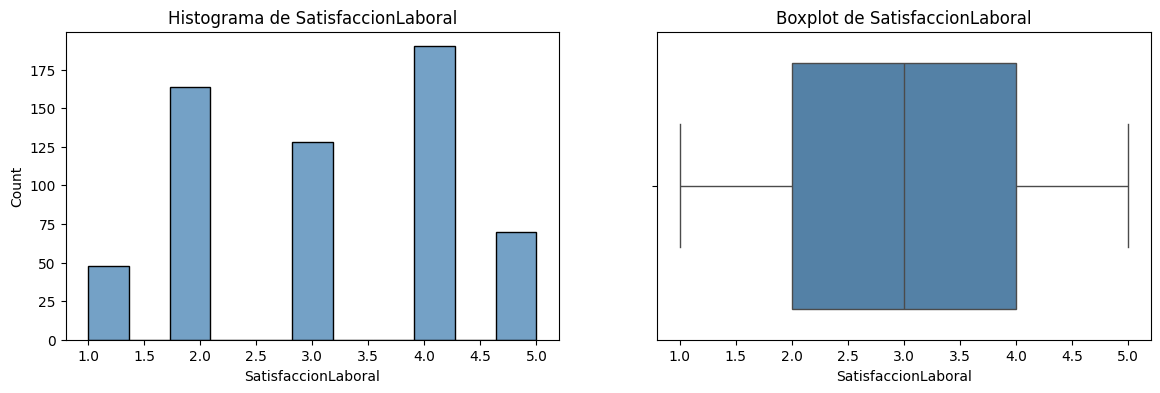

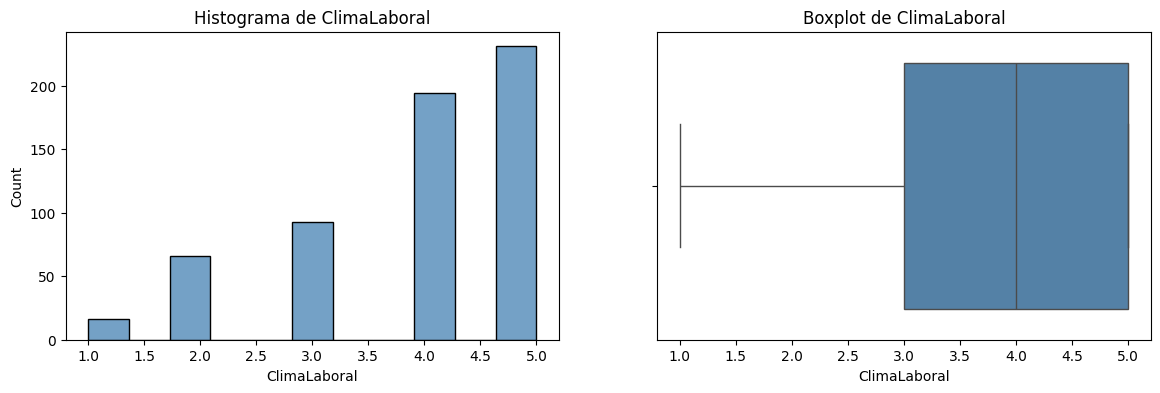

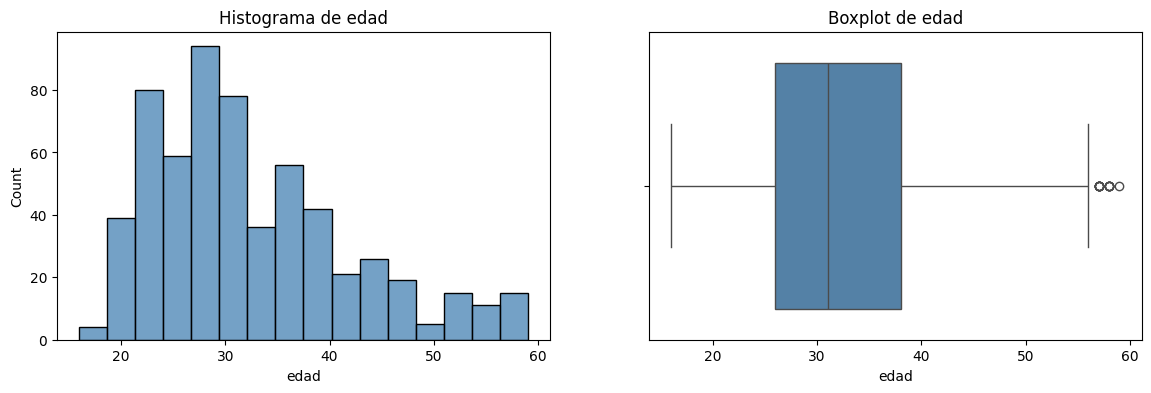

In [5]:

#Para cada variable numérica, realizamos un histograma y un boxplot
num_cols = df_bl.select_dtypes(include=['int64', 'float64']).columns

# Histogramas
for col in num_cols:

  fig, ax = plt.subplots(1, 2, figsize=(14, 4))

  sns.histplot(data=df_bl, x=col, ax=ax[0], color="steelblue")
  ax[0].title.set_text(f"Histograma de {col}")

  sns.boxplot(data=df_bl, x=col, ax=ax[1], color="steelblue")
  ax[1].title.set_text(f"Boxplot de {col}")

  plt.show()



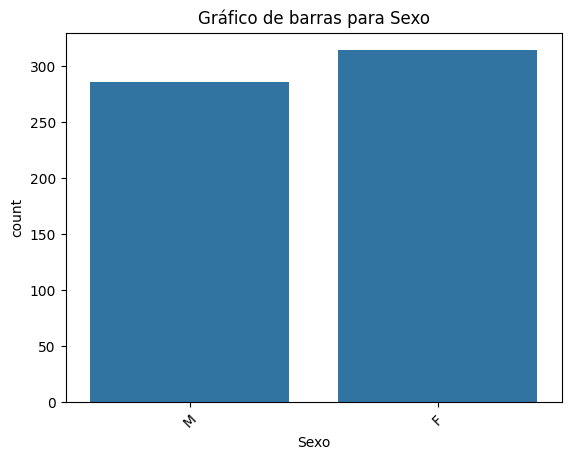

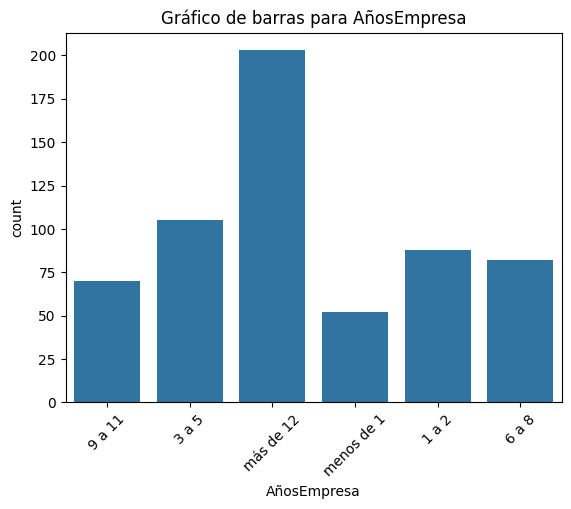

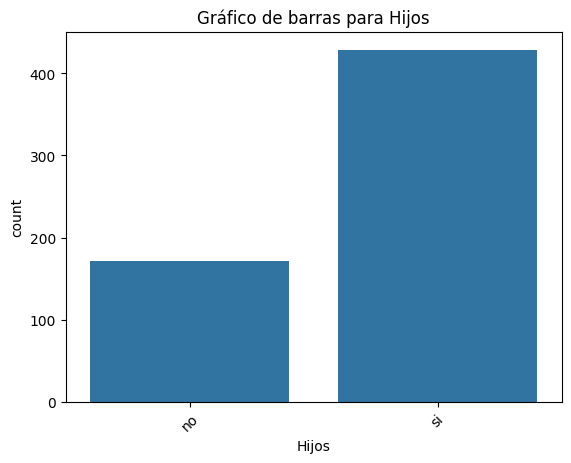

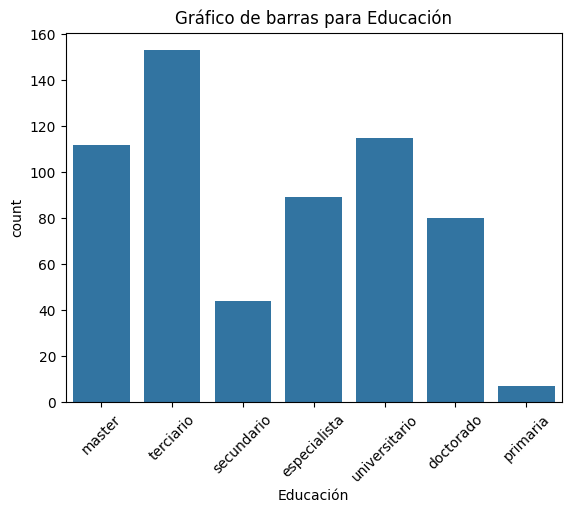

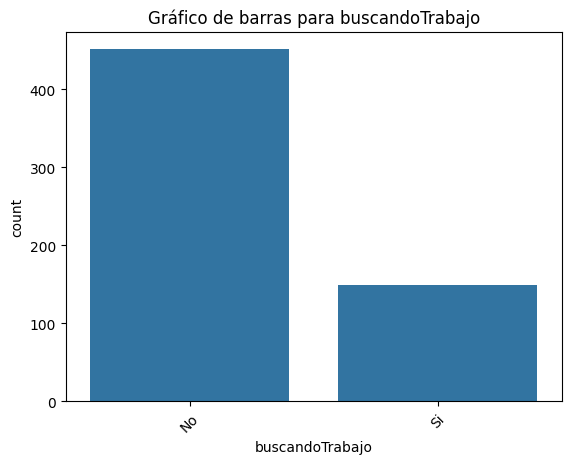

In [ ]:
#Para cada variable categórica hacemos un grafico de barras con la cantidad
for col in df_bl.select_dtypes(include='object').columns:
    plt.figure()
    ax = sns.countplot(x=col, data=df_bl)
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.title(f"Gráfico de barras para {col}")
    plt.show()

**ANÁLISIS MULTIVARIANTE**

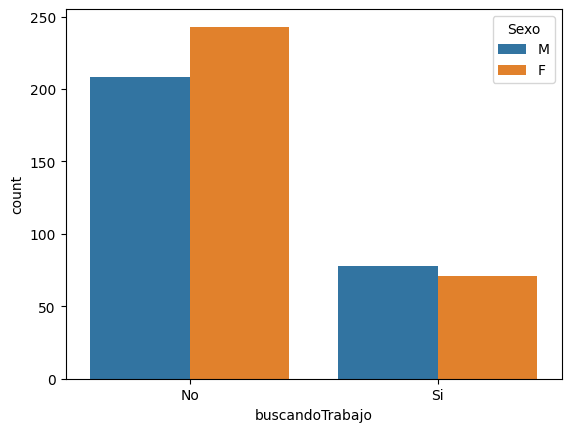

In [6]:
# Buscando trabajo vs Sexo
sns.countplot(data = df_bl, x = "buscandoTrabajo", hue = "Sexo")
plt.show()

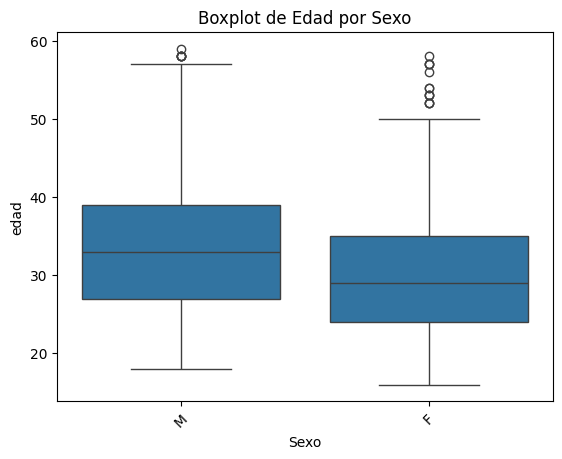

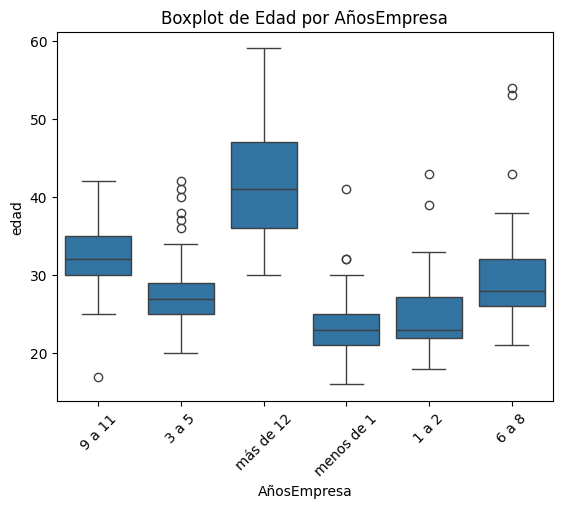

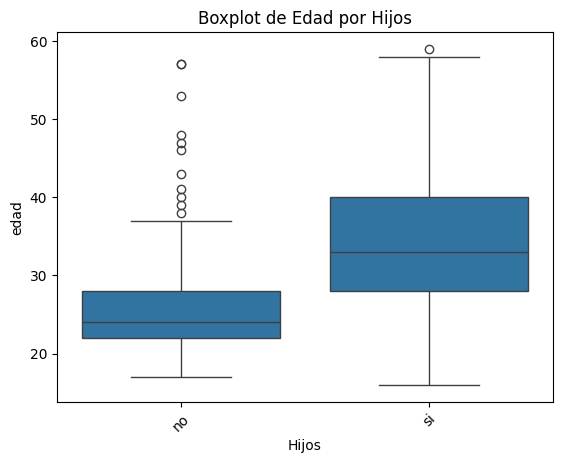

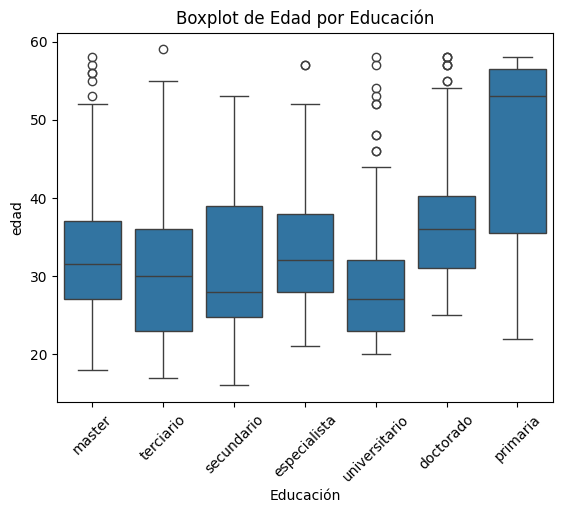

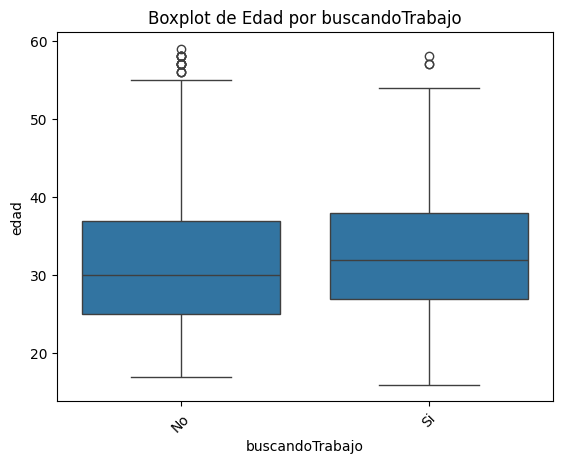

In [7]:
#CONFRONTACIÓN DE UNA VARIABLE CONTRA TODAS (EDAD)
#Para cada variable categórica hacemos boxplots con la variable numérica EDAD
for col in df_bl.select_dtypes(include='object').columns:
  plt.figure()
  sns.boxplot(x=col, y="edad", data=df_bl)
  plt.xticks(rotation=45)
  plt.xlabel(col)
  plt.ylabel("edad")
  plt.title(f"Boxplot de Edad por {col}")
  plt.show()



Revisamos si hay inconsistencias en los datos, por ejemplo personas muy jóvenes con muchos años en la empresa:

In [8]:
df_bl[(df_bl["edad"]< 20) & (df_bl["AñosEmpresa"].isin(["9 a 11", "Más de 11", "6 a 8"]))]

,Sexo,AñosEmpresa,Hijos,SatisfaccionLaboral,Educación,ClimaLaboral,edad,buscandoTrabajo
419,F,9 a 11,no,4,terciario,5,17,No


Si existieran registros inconsistentes (por ejemplo, alguien con menos de 20 años y muchos años en la empresa), los eliminaríamos del dataset:

In [9]:
# Eliminamos registros inconsistentes (si los hubiera)
df_bl = df_bl[~((df_bl["edad"]< 20) & (df_bl["AñosEmpresa"].isin(["9 a 11", "Más de 11", "6 a 8"])))].copy()
df_bl.info()

<class 'pandas.core.frame.DataFrame'>
Index: 599 entries, 0 to 599
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Sexo                 599 non-null    object
 1   AñosEmpresa          599 non-null    object
 2   Hijos                599 non-null    object
 3   SatisfaccionLaboral  599 non-null    int64 
 4   Educación            599 non-null    object
 5   ClimaLaboral         599 non-null    int64 
 6   edad                 599 non-null    int64 
 7   buscandoTrabajo      599 non-null    object
dtypes: int64(3), object(5)
memory usage: 42.1+ KB


### Modelado

In [10]:
#importamos los paquetes que vamos a necesitar
from sklearn.tree import DecisionTreeClassifier #arbol de clasificación
from sklearn.model_selection import train_test_split #funcion para dividir datos en train y test
from sklearn.metrics import make_scorer, accuracy_score, recall_score, confusion_matrix
from sklearn.tree import plot_tree
import numpy as np

#LA SINTAXIS EN PYTHON PARA APLICAR UN MODELO DE ÁRBOLES ES LA SIGUIENTE
#modelo = DecisionTreeClassifier(max_depth=N)
#modelo.fit(X_train, y_train)

#Como podemos ver, necesitamos separar las variables predictoras (X) de la variable predicha (y).
#Por otro lado, como en todo modelo predictivo, vamos a realizar una separación de los datos en entrenamiento (train) y prueba (test)



En cuanto a las variables categóricas, en Python no hay un paquete que permita introducir directamente datos cualitativos en un árbol de tipo CART. Por esta razón, emplearemos el método de codificación "one-hot encoding" para convertir nuestros datos a formato numérico antes de proceder a construir el árbol de decisión.  
One-hot encoding es un proceso para convertir variables categóricas a numericas para ser proporcionadas a los algoritmos de ML para hacer un mejor trabajo en la predicción. Para cada valor único de la columna categórica se crea una columna nueva binaria (0 o 1).

In [11]:
#DEFINIMOS LA FUNCIÓN one_hot_encoding para transformar las variables categóricas
def one_hot_encoding(df, categorical_features, final_columns=None, drop_originals=True):
  """
    Realiza codificación one-hot en las características categóricas especificadas de un DataFrame.
    Esta función aplica la codificación one-hot a la lista dada de características categóricas
    en el DataFrame utilizando el método get_dummies de pandas. Opcionalmente, puede eliminar
    las columnas categóricas originales del DataFrame. Además, permite asegurar que el DataFrame
    resultante incluya un conjunto específico de columnas, rellenando con ceros las que no estén presentes.

    Parámetros:
    - df (pandas.DataFrame): El DataFrame que contiene los datos.
    - categorical_features (list): Lista de columnas categóricas a codificar.
    - final_columns (list): Lista de columnas que deben estar presentes en el DataFrame final.
                            Se agregarán como columnas de ceros si no existen después de la codificación.
    - drop_originals (bool): Indica si se deben eliminar las columnas originales.
                             El valor predeterminado es True.

    Retorna:
    - pandas.DataFrame: DataFrame con las características categóricas codificadas y, opcionalmente,
                        sin las columnas categóricas originales. Incluye todas las columnas especificadas en final_columns.
    """

  # Realizar codificación one-hot
  encoded_features = pd.get_dummies(df[categorical_features], drop_first=True)
  df = pd.concat([df, encoded_features*1], axis=1)

  if drop_originals:
    df = df.drop(categorical_features, axis=1)

  # Asegurar que todas las columnas finales estén presentes
  if final_columns is not None:
    for column in final_columns:
      if column not in df.columns:
        df[column] = 0  # Añadir la columna faltante con ceros

  return df


In [12]:
#Aplicamos one hot encoding a nuestro dataframe
vars_cat = df_bl.select_dtypes(include='object').columns
df_bl_encoded = one_hot_encoding(df_bl, vars_cat)
df_bl_encoded.head()

,SatisfaccionLaboral,ClimaLaboral,edad,Sexo_M,AñosEmpresa_3 a 5,AñosEmpresa_6 a 8,AñosEmpresa_9 a 11,AñosEmpresa_menos de 1,AñosEmpresa_más de 12,Hijos_si,Educación_especialista,Educación_master,Educación_primaria,Educación_secundario,Educación_terciario,Educación_universitario,buscandoTrabajo_Si
0,3,4,37,1,0,0,1,0,0,0,0,1,0,0,0,0,0
1,4,4,28,0,1,0,0,0,0,0,0,0,0,0,1,0,0
2,1,4,32,0,0,0,0,0,1,1,0,0,0,1,0,0,0
3,5,5,55,1,0,0,0,0,1,1,0,1,0,0,0,0,0
4,2,3,21,1,0,0,0,1,0,0,1,0,0,0,0,0,0


In [15]:
#Separamos en train y test, por un lado las variables predictoras (X) y por otro la predicha (y)
X_train, X_test, y_train, y_test = train_test_split(df_bl_encoded.drop(columns = ["buscandoTrabajo_Si"]),
                                                    df_bl_encoded.buscandoTrabajo_Si,
                                                    test_size=0.2,
                                                    random_state=17,
                                                    stratify=df_bl_encoded.buscandoTrabajo_Si)

In [ ]:
X_test

,SatisfaccionLaboral,ClimaLaboral,edad,Sexo_M,AñosEmpresa_3 a 5,AñosEmpresa_6 a 8,AñosEmpresa_9 a 11,AñosEmpresa_menos de 1,AñosEmpresa_más de 12,Hijos_si,Educación_especialista,Educación_master,Educación_primaria,Educación_secundario,Educación_terciario,Educación_universitario
355,2,5,49,0,0,0,0,0,1,1,0,0,0,0,1,0
17,3,4,20,0,0,0,0,1,0,0,0,0,0,0,0,1
472,5,4,26,0,0,1,0,0,0,1,0,0,0,0,1,0
382,4,5,33,1,0,0,1,0,0,1,0,0,0,0,0,0
410,2,3,20,0,1,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363,3,5,31,0,0,0,1,0,0,1,0,0,0,0,1,0
2,1,4,32,0,0,0,0,0,1,1,0,0,0,1,0,0
91,2,3,39,1,0,0,1,0,0,1,0,0,0,0,1,0
21,2,5,22,0,0,0,0,0,0,0,0,0,0,0,0,1


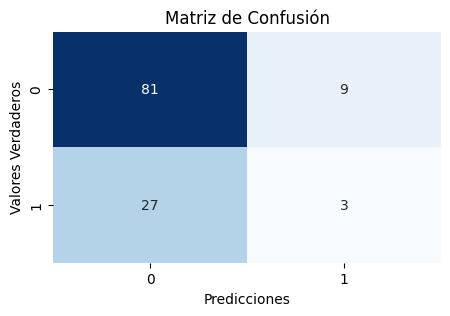

In [23]:
#CREAMOS EL MODELO CON LOS DATOS TRAIN
clf = DecisionTreeClassifier(max_depth=5)
clf.fit(X_train, y_train)

#CALCULAMOS LAS PREDICCIONES

#CALCULAMOS LA MATRIZ DE CONFUSION
conf_matrix = confusion_matrix(y_test, y_pred, labels = [0,1])

plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión')
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')

plt.show()

In [17]:
#CALCULAMOS LA PRECISIÓN (ACCURACY) DEL MODELO
acc = accuracy_score(y_test, y_pred)
print(f"Precisión (Accuracy) del modelo: {acc:.4f}")
print(f"Es decir, el modelo acierta el {acc*100:.2f}% de las veces sobre el conjunto de prueba.")

Precisión (Accuracy) del modelo: 0.7083
Es decir, el modelo acierta el 70.83% de las veces sobre el conjunto de prueba.


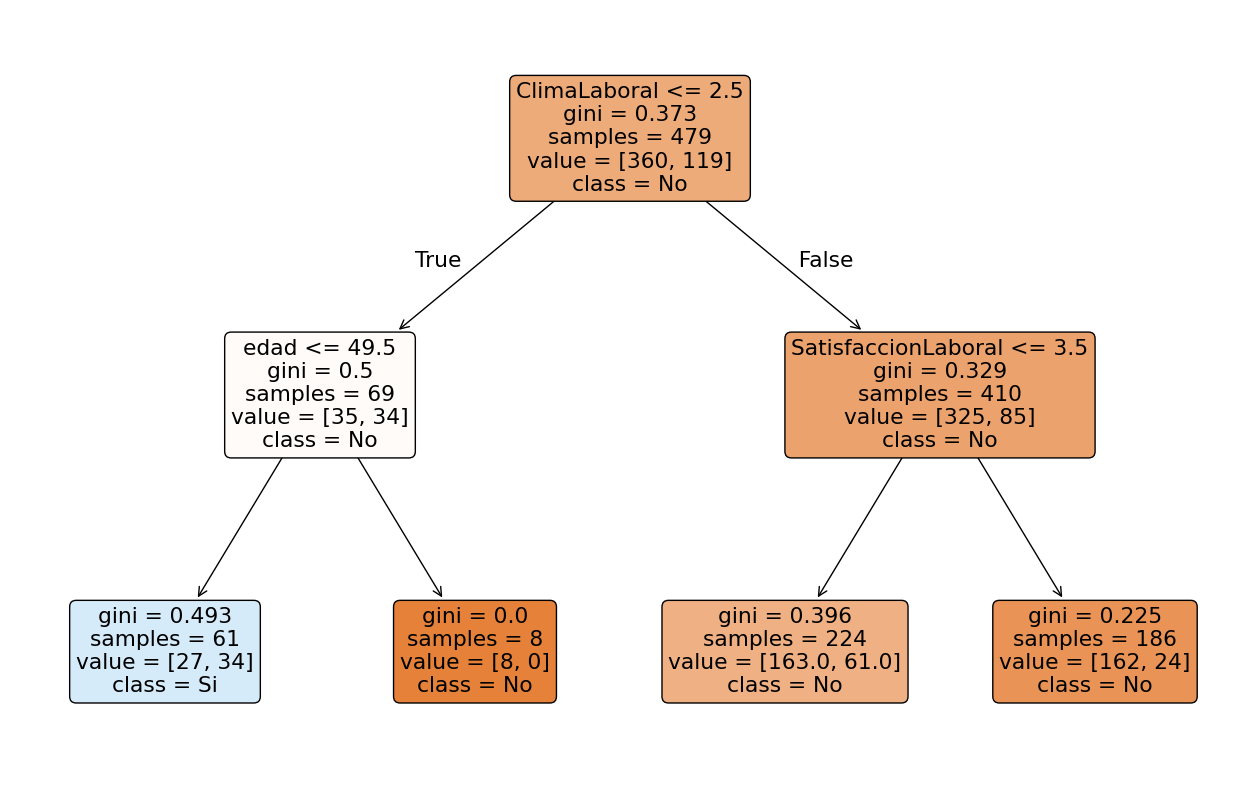

In [22]:
#GRAFICAMOS EL ARBOL
plt.figure(figsize=(16, 10))
plot_tree(clf, filled=True, class_names = np.unique(df_bl.buscandoTrabajo), feature_names=X_train.columns, rounded=True)
plt.show()

### b. Predicción para Marcos y Sergio

Utilizamos el modelo entrenado para predecir si **Marcos** y **Sergio** están buscando empleo activamente.

| Nombre | Edad | Sexo | Años en la empresa | Hijos a cargo | Educación | Satisfacción laboral | Percepción del clima |
|--------|------|------|---------------------|---------------|-----------|----------------------|----------------------|
| Marcos | 29   | M    | 1 a 2               | Sí            | Universitario | 2                | 4                    |
| Sergio | 36   | M    | Menos de 1          | No            | Secundario    | 5                | 2                    |

In [ ]:
#Creamos un DataFrame con los datos de Marcos y Sergio
nuevos_empleados = pd.DataFrame({
    "Edad": [29, 36],
    "Sexo": ["M", "M"],
    "AñosEmpresa": ["1 a 2", "Menos de 1"],
    "HijosCargo": ["Si", "No"],
    "Educacion": ["Universitario", "Secundario"],
    "SatisfaccionLaboral": [2, 5],
    "PercepcionClima": [4, 2]
}, index=["Marcos", "Sergio"])

nuevos_empleados

,Edad,Sexo,AñosEmpresa,HijosCargo,Educacion,SatisfaccionLaboral,PercepcionClima
Marcos,29,M,1 a 2,Si,Universitario,2,4
Sergio,36,M,Menos de 1,No,Secundario,5,2


In [ ]:
#Aplicamos one-hot encoding a los nuevos datos, asegurando que tengan las mismas columnas que X_train
#Usamos final_columns = X_train.columns para garantizar la misma estructura
vars_cat_nuevos = nuevos_empleados.select_dtypes(include='object').columns
nuevos_encoded = one_hot_encoding(nuevos_empleados, vars_cat_nuevos, final_columns=X_train.columns)

#Reordenamos las columnas para que coincidan con las de X_train
nuevos_encoded = nuevos_encoded[X_train.columns]
nuevos_encoded

,SatisfaccionLaboral,ClimaLaboral,edad,Sexo_M,AñosEmpresa_3 a 5,AñosEmpresa_6 a 8,AñosEmpresa_9 a 11,AñosEmpresa_menos de 1,AñosEmpresa_más de 12,Hijos_si,Educación_especialista,Educación_master,Educación_primaria,Educación_secundario,Educación_terciario,Educación_universitario
Marcos,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Sergio,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
#Realizamos la predicción
predicciones = clf.predict(nuevos_encoded)
probabilidades = clf.predict_proba(nuevos_encoded)

#Mostramos los resultados
resultados = pd.DataFrame({
    "Empleado": nuevos_encoded.index,
    "¿Busca trabajo?": ["Si" if p == 1 else "No" for p in predicciones],
    "Prob. No busca": probabilidades[:, 0],
    "Prob. Si busca": probabilidades[:, 1]
})

resultados

,Empleado,¿Busca trabajo?,Prob. No busca,Prob. Si busca
0,Marcos,No,0.625,0.375
1,Sergio,No,0.625,0.375


In [ ]:
#Conclusión
for nombre, pred, prob in zip(nuevos_encoded.index, predicciones, probabilidades):
    estado = "SÍ está buscando empleo activamente" if pred == 1 else "NO está buscando empleo activamente"
    print(f"→ Según el modelo, {nombre} {estado} (probabilidad: {prob[pred]*100:.2f}%)")

→ Según el modelo, Marcos NO está buscando empleo activamente (probabilidad: 62.50%)
→ Según el modelo, Sergio NO está buscando empleo activamente (probabilidad: 62.50%)
